In [45]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

In [46]:
df = pd.read_csv('https://raw.githubusercontent.com/Explore-AI/Public-Data/master/Data/regression_sprint/mtcars.csv', index_col=0)
df.head(5)

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
model,,,,,,,,,,,
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [47]:
df.shape

(32, 11)

In [48]:
fig = plt.figure(figsize=(8,7))

ax = fig.add_subplot(111, projection = '3d')

ax.set_zlabel('MPG')
ax.set_xlabel('No. of Cylinders')
ax.set_ylabel('Weight (1000lbs)')

ax.scatter(df['cyl'], df['wt'], df['mpg'])

In [49]:
from sklearn.linear_model import LinearRegression

y = df['mpg']
X = df.drop('mpg', axis=1)
 
ld = LinearRegression()


In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=1)

ld.fit(X_train, y_train)

LinearRegression()

In [51]:
beta_0 = float(ld.intercept_)

In [52]:
print("Intercept: ", beta_0)

Intercept:  8.465282572242598


In [53]:
beta_js = pd.DataFrame(ld.coef_, X.columns, columns=['Coefficients'])

In [54]:
beta_js

,Coefficients
cyl,0.190203
disp,0.008613
hp,-0.022868
drat,1.477014
wt,-3.564785
qsec,0.924358
vs,-1.248904
am,1.340890
gear,0.482458
carb,-0.187354


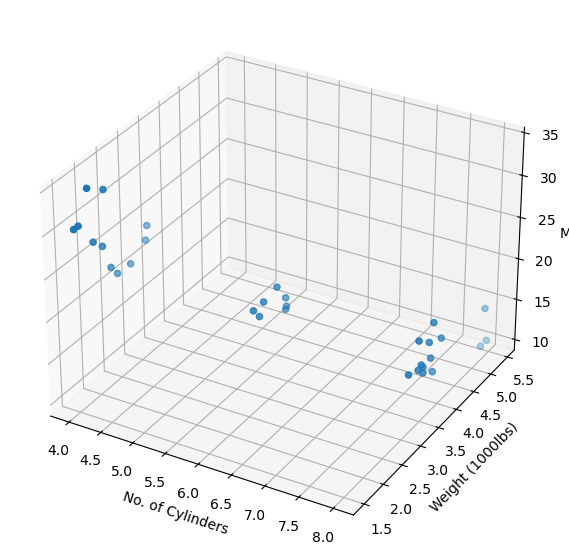

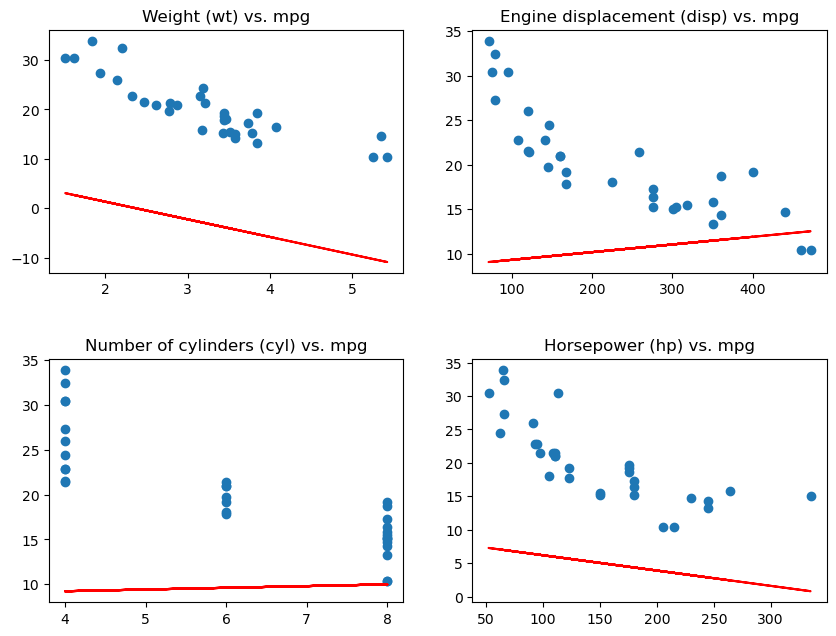

In [55]:
fig, axs = plt.subplots(2, 2, figsize=(9,7))

axs[0,0].scatter(df['wt'], df['mpg'])
axs[0,0].plot(df['wt'], ld.intercept_ + ld.coef_[4]*df['wt'], color='red')
axs[0,0].title.set_text('Weight (wt) vs. mpg')

axs[0,1].scatter(df['disp'], df['mpg'])
axs[0,1].plot(df['disp'], ld.intercept_ + ld.coef_[1]*df['disp'], color='red')
axs[0,1].title.set_text('Engine displacement (disp) vs. mpg')

axs[1,0].scatter(df['cyl'], df['mpg'])
axs[1,0].plot(df['cyl'], ld.intercept_ + ld.coef_[0]*df['cyl'], color='red')
axs[1,0].title.set_text('Number of cylinders (cyl) vs. mpg')

axs[1,1].scatter(df['hp'], df['mpg'])
axs[1,1].plot(df['hp'], ld.intercept_ + ld.coef_[2]*df['hp'], color='red')
axs[1,1].title.set_text('Horsepower (hp) vs. mpg')

fig.tight_layout(pad=3.0)

plt.show()

In [56]:
slr = LinearRegression()

slr.fit(X_train[['disp']], y_train)

LinearRegression()

In [57]:
from sklearn import metrics
import math

In [58]:
# dictionary of results
results_dict = {'Training MSE':
                    {
                        "SLR": metrics.mean_squared_error(y_train, slr.predict(X_train[['disp']])),
                        "MLR": metrics.mean_squared_error(y_train, ld.predict(X_train))
                    },
                'Test MSE':
                    {
                        "SLR": metrics.mean_squared_error(y_test, slr.predict(X_test[['disp']])),
                        "MLR": metrics.mean_squared_error(y_test, ld.predict(X_test))
                    },
                'Test RMSE':
                    {
                        "SLR": math.sqrt(metrics.mean_squared_error(y_test, slr.predict(X_test[['disp']]))),
                        "MLR": math.sqrt(metrics.mean_squared_error(y_test, ld.predict(X_test)))
                    }
                }

In [59]:
results_df = pd.DataFrame(data=results_dict)

In [60]:
results_df

,Training MSE,Test MSE,Test RMSE
SLR,8.201521,20.500165,4.527711
MLR,3.737534,11.520901,3.394245


In [61]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
mpg,32.0,20.090625,6.026948,10.400,15.42500,19.200,22.80,33.900
cyl,32.0,6.187500,1.785922,4.000,4.00000,6.000,8.00,8.000
disp,32.0,230.721875,123.938694,71.100,120.82500,196.300,326.00,472.000
hp,32.0,146.687500,68.562868,52.000,96.50000,123.000,180.00,335.000
drat,32.0,3.596563,0.534679,2.760,3.08000,3.695,3.92,4.930
wt,32.0,3.217250,0.978457,1.513,2.58125,3.325,3.61,5.424
qsec,32.0,17.848750,1.786943,14.500,16.89250,17.710,18.90,22.900
vs,32.0,0.437500,0.504016,0.000,0.00000,0.000,1.00,1.000
am,32.0,0.406250,0.498991,0.000,0.00000,0.000,1.00,1.000
gear,32.0,3.687500,0.737804,3.000,3.00000,4.000,4.00,5.000


In [62]:
fig, axs = plt.subplots(2,5, figsize=(14,6),)
fig.subplots_adjust(hspace = 0.5, wspace=.2)
axs = axs.ravel()

for index, column in enumerate(df.columns):
    axs[index-1].set_title("{} vs. mpg".format(column),fontsize=16)
    axs[index-1].scatter(x=df[column],y=df['mpg'],color='blue',edgecolor='k')

fig.tight_layout(pad=1)

In [63]:
df1 = df.copy()


In [64]:
from seaborn import pairplot
g = pairplot(df1.drop('mpg', axis='columns'))
g.fig.set_size_inches(9,9)

In [65]:
corr = df1.drop('mpg', axis='columns').corr()


In [66]:
from statsmodels.graphics.correlation import plot_corr


In [67]:
fig=plot_corr(corr,xnames=corr.columns)


In [68]:
import statsmodels.formula.api as sm

In [69]:
formula_str = df1.columns[0]+' ~ '+'+'.join(df1.columns[1:])
formula_str

'mpg ~ cyl+disp+hp+drat+wt+qsec+vs+am+gear+carb'

In [70]:
model=sm.ols(formula=formula_str, data=df1)

In [71]:
fitted = model.fit()

In [72]:
print(fitted.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.869
Model:                            OLS   Adj. R-squared:                  0.807
Method:                 Least Squares   F-statistic:                     13.93
Date:                Mon, 03 Aug 2026   Prob (F-statistic):           3.79e-07
Time:                        14:19:28   Log-Likelihood:                -69.855
No. Observations:                  32   AIC:                             161.7
Df Residuals:                      21   BIC:                             177.8
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     12.3034     18.718      0.657      0.5

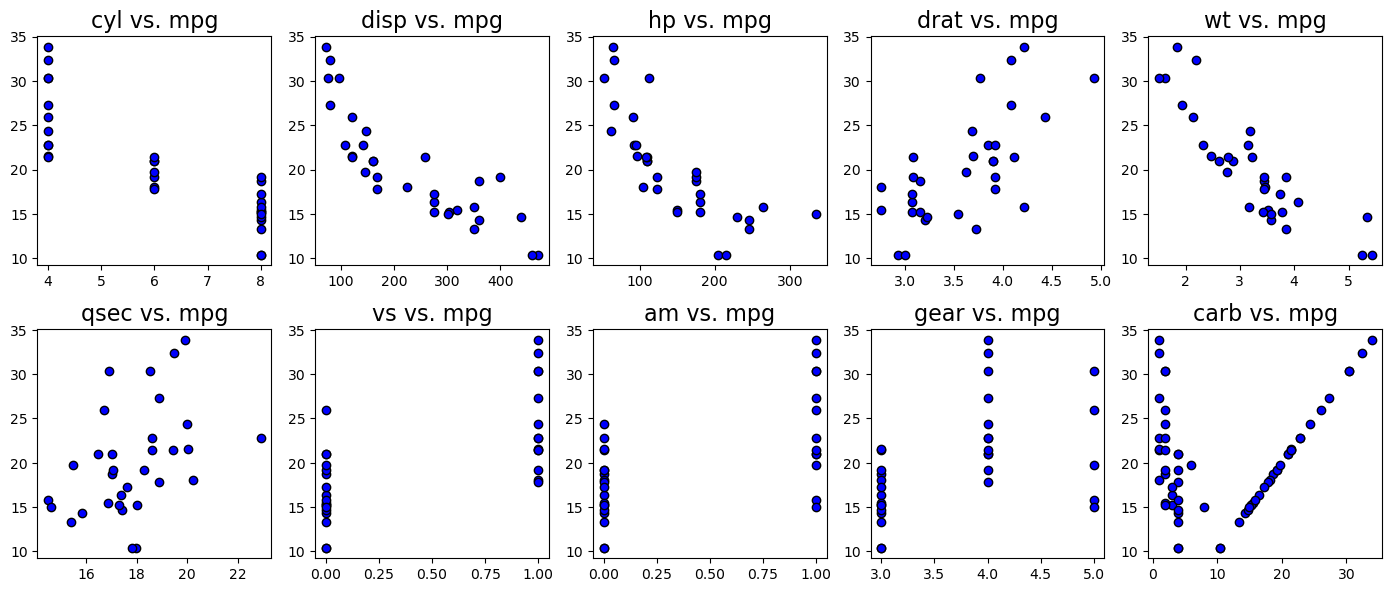

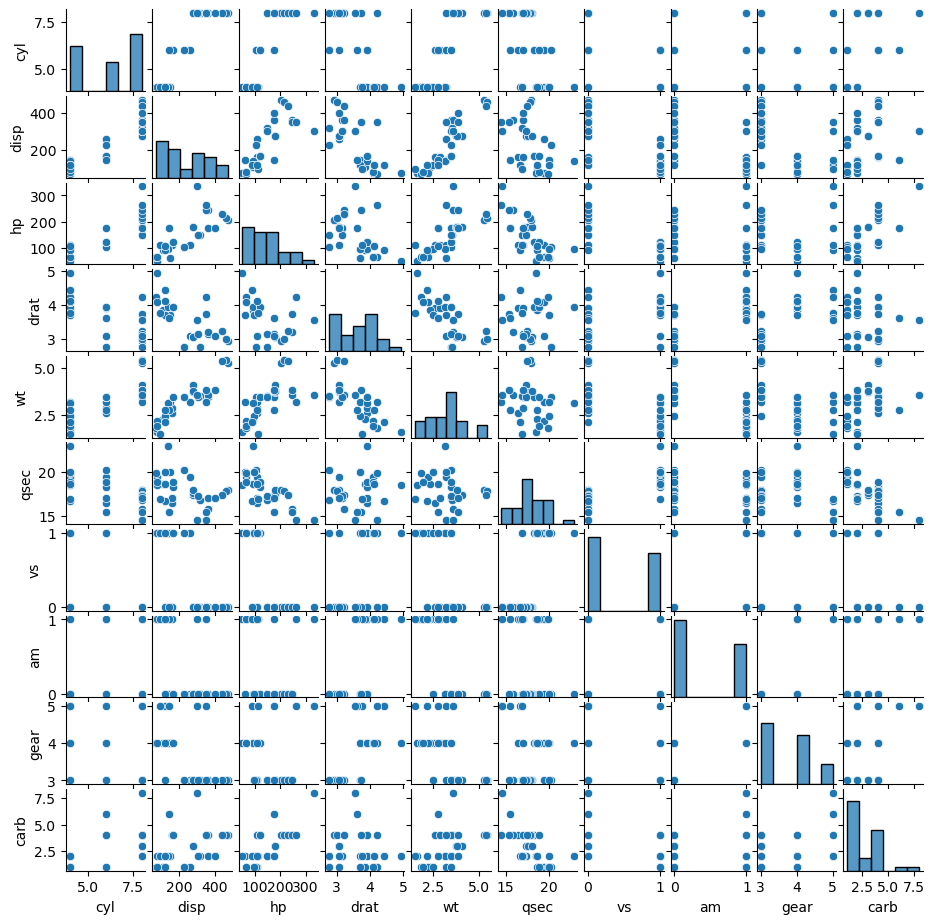

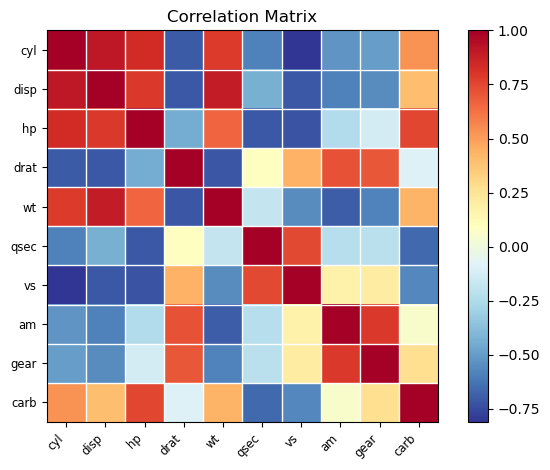

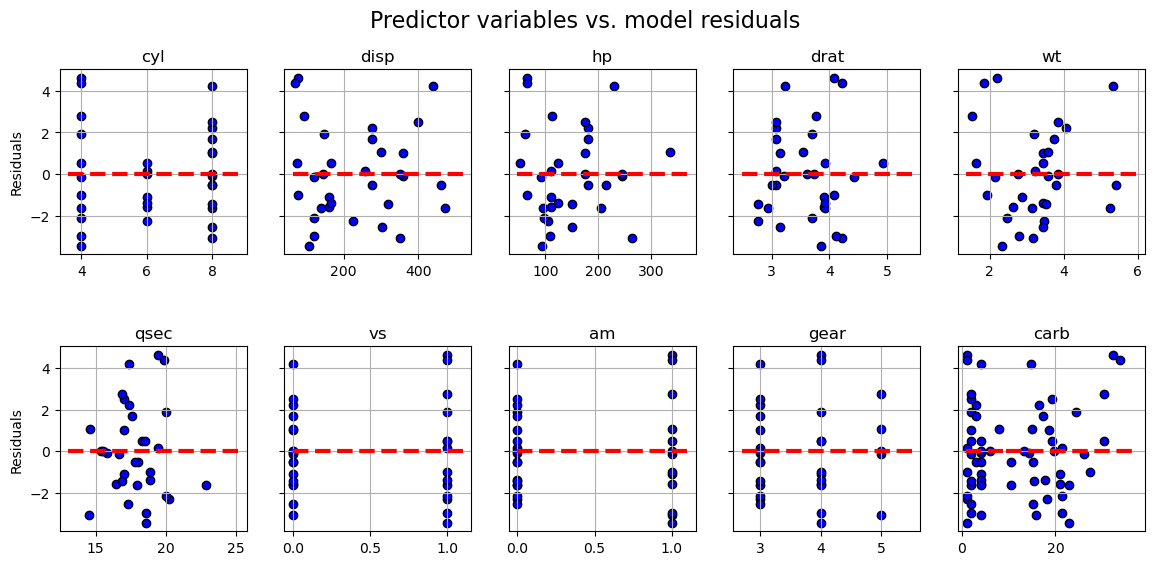

In [73]:
fig, axs = plt.subplots(2,5, figsize=(14,6),sharey=True)
fig.subplots_adjust(hspace = 0.5, wspace=.2)
fig.suptitle('Predictor variables vs. model residuals', fontsize=16)
axs = axs.ravel()

for index, column in enumerate(df.columns):
    axs[index-1].set_title("{}".format(column),fontsize=12)
    axs[index-1].scatter(x=df[column],y=fitted.resid,color='blue',edgecolor='k')
    axs[index-1].grid(True)
    xmin = min(df[column])
    xmax = max(df[column])
    axs[index-1].hlines(y=0,xmin=xmin*0.9,xmax=xmax*1.1,color='red',linestyle='--',lw=3)
    if index == 1 or index == 6:
        axs[index-1].set_ylabel('Residuals')
plt.show()

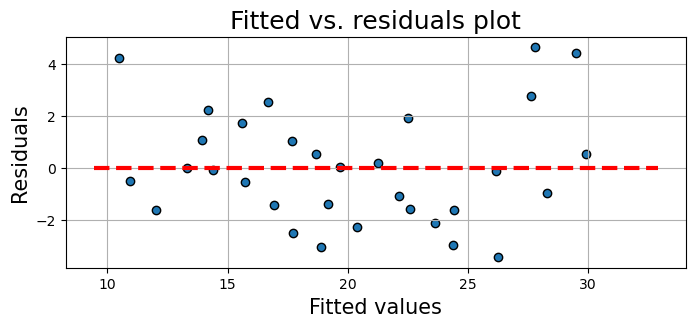

In [74]:
plt.figure(figsize=(8,3))
p=plt.scatter(x=fitted.fittedvalues,y=fitted.resid,edgecolor='k')
xmin = min(fitted.fittedvalues)
xmax = max(fitted.fittedvalues)
plt.hlines(y=0,xmin=xmin*0.9,xmax=xmax*1.1,color='red',linestyle='--',lw=3)
plt.xlabel("Fitted values",fontsize=15)
plt.ylabel("Residuals",fontsize=15)
plt.title("Fitted vs. residuals plot",fontsize=18)
plt.grid(True)
plt.show()

In [75]:
import statsmodels.stats.api as sms

# 1. Calculate residuals
residuals = fitted.resid

# 2. Perform Breusch-Pagan test
bp_test_result = sms.het_breuschpagan(residuals, fitted.model.exog)
print("Breusch-Pagan Test Results:")
print("LM Statistic:", bp_test_result[0])
print("LM-Test p-value:", bp_test_result[1])
print("F-Statistic:", bp_test_result[2])
print("F-Test p-value:", bp_test_result[3])

Breusch-Pagan Test Results:
LM Statistic: 14.913588960622171
LM-Test p-value: 0.13524415065665535
F-Statistic: 1.8329499825989768
F-Test p-value: 0.1163458435391346


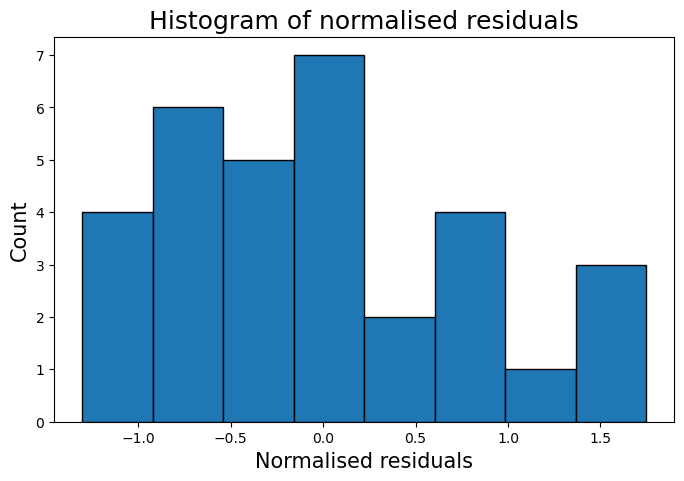

In [76]:
plt.figure(figsize=(8,5))
plt.hist(fitted.resid_pearson,bins=8,edgecolor='k')
plt.ylabel('Count',fontsize=15)
plt.xlabel('Normalised residuals',fontsize=15)
plt.title("Histogram of normalised residuals",fontsize=18)
plt.show()

In [77]:
from statsmodels.graphics.gofplots import qqplot

<Figure size 800x500 with 0 Axes>

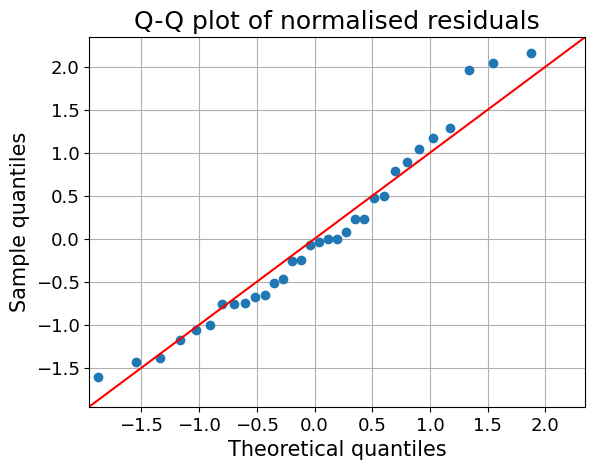

In [78]:
plt.figure(figsize=(8,5))
fig=qqplot(fitted.resid_pearson,line='45',fit='True')
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.xlabel("Theoretical quantiles",fontsize=15)
plt.ylabel("Sample quantiles",fontsize=15)
plt.title("Q-Q plot of normalised residuals",fontsize=18)
plt.grid(True)
plt.show()

In [79]:
from statsmodels.stats.outliers_influence import OLSInfluence as influence

In [80]:
inf=influence(fitted)

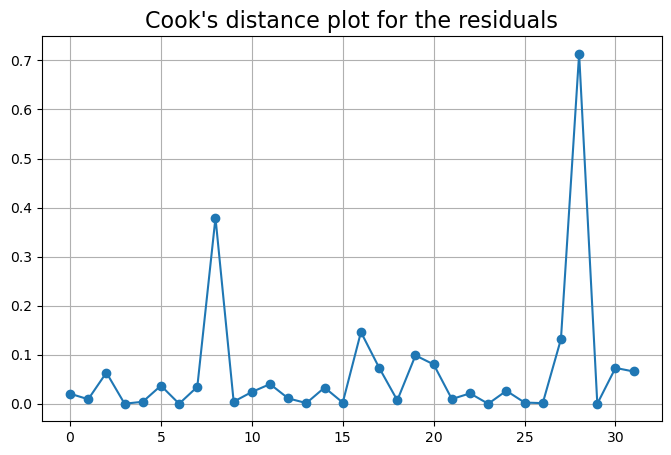

In [81]:
(c, p) = inf.cooks_distance
plt.figure(figsize=(8, 5))
plt.title("Cook's distance plot for the residuals", fontsize=16)
plt.plot(np.arange(len(c)), c, marker='o', linestyle='-')
plt.grid(True)
plt.show()

Exercise:
The dataset
For this exercise, we make use of the enviro_indicators dataset. The dataset comprises socio-economic and environmental data collected from various countries, focusing on factors related to sustainable development. It includes information such as forest coverage, biodiversity index, protected areas, rural population, and deforestation rates, aimed at understanding the relationship between human activities and land degradation.

The following are the descriptions of the columns in our dataset:

country: Name of the country.
forest_coverage: Percentage of land covered by forests. This indicator represents the extent of forested areas within the total land area of each country.
biodiversity_index: Index representing the biodiversity level in each country. This indicator provides a measure of the variety and variability of organisms within each country's ecosystem.
protected_areas: Percentage of land designated as protected areas. This indicator reflects the proportion of land that is legally protected and managed for conservation purposes.
deforestation_rate: Annual rate of deforestation (%). This indicator quantifies the percentage of forested land that is lost each year due to deforestation activities.
carbon_sequestration: Amount of carbon sequestered by forests (metric tons per hectare). This indicator measures the capacity of forests to absorb and store carbon dioxide from the atmosphere, thus helping mitigate climate change.
soil_erosion: Rate of soil erosion (tons per hectare per year). This indicator indicates the amount of soil that is lost or displaced annually due to erosion, which can have detrimental effects on land productivity and ecosystem health.
land_degradation: Percentage of land classified as degraded. This indicator represents the proportion of land that has suffered a decline in its ecological condition, often resulting from unsustainable land use practices.
rural_population: Percentage of population living in rural areas. This indicator reflects the proportion of a country's population residing in rural areas rather than urban centres.
population_density: Population density (people per square kilometre). This indicator quantifies the average number of people living within a unit area of land, providing insights into the distribution of human populations across different countries.

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import statsmodels.graphics.correlation as sgc
from statsmodels.graphics.gofplots import qqplot
import statsmodels.stats.api as sms
from statsmodels.stats.outliers_influence import OLSInfluence


In [83]:
environmental_indicators = pd.read_csv('https://raw.githubusercontent.com/Explore-AI/Public-Data/master/Data/regression_sprint/enviro_indicators.csv', index_col=0)
environmental_indicators.head(10)

,forest_coverage,biodiversity_index,protected_areas,deforestation_rate,carbon_sequestration,soil_erosion,land_degradation,rural_population,population_density
Country,,,,,,,,,
Vietnam,36.217808,6.505159,14.832708,36.583106,53.128459,7.987880,55.020903,35.912142,468.715839
Guinea-Bissau,76.550001,94.888554,23.994363,123.384939,279.836286,13.013811,41.655073,34.639379,351.054600
Bosnia and Herzegovina,61.239576,96.563203,9.932348,115.743745,237.834951,13.037065,26.951490,78.380633,289.329973
Lesotho,51.906094,80.839735,33.076894,111.752369,149.948515,11.179719,27.460479,43.585863,57.616482
Indonesia,20.921305,30.461377,7.609273,46.450326,103.939415,2.715506,46.297784,73.522793,311.353541
Singapore,20.919616,9.767211,39.541043,25.249501,201.926827,16.870747,54.855513,57.868318,495.126387
Saint Lucia,14.065853,68.423303,32.028567,76.130581,474.309367,7.094821,54.354321,67.688678,78.641167
Turkmenistan,70.632330,44.015249,11.955049,73.358093,195.441319,4.543852,48.993777,50.158226,263.981530
Kenya,52.078051,12.203823,5.193274,36.843972,283.455780,1.774728,42.101582,54.614233,439.912805


Exercise 1

Print the first few rows of the dataset, the summary statistics, and check for missing values. Doing this provides an overview of the structure of the data and highlights whether there are any issues with missing data.



In [84]:
print(environmental_indicators.head())

                        forest_coverage  biodiversity_index  protected_areas  \
Country                                                                        
Vietnam                       36.217808            6.505159        14.832708   
Guinea-Bissau                 76.550001           94.888554        23.994363   
Bosnia and Herzegovina        61.239576           96.563203         9.932348   
Lesotho                       51.906094           80.839735        33.076894   
Indonesia                     20.921305           30.461377         7.609273   

                        deforestation_rate  carbon_sequestration  \
Country                                                            
Vietnam                          36.583106             53.128459   
Guinea-Bissau                   123.384939            279.836286   
Bosnia and Herzegovina          115.743745            237.834951   
Lesotho                         111.752369            149.948515   
Indonesia                      

In [85]:
print(environmental_indicators.describe())

       forest_coverage  biodiversity_index  protected_areas  \
count        32.000000           32.000000        32.000000   
mean         40.484972           49.873676        22.542576   
std          19.529573           32.201278        10.338851   
min          11.440915            3.438852         5.193274   
25%          22.810674           24.308070        14.113293   
50%          38.226980           46.766470        24.319532   
75%          52.603530           81.348239        31.716570   
max          77.893690           96.958463        39.541043   

       deforestation_rate  carbon_sequestration  soil_erosion  \
count           32.000000             32.000000     32.000000   
mean            69.063387            255.649653      9.874722   
std             30.100259            132.047729      5.464372   
min             18.113759             53.128459      1.315169   
25%             46.131162            158.644367      5.113528   
50%             70.838794            225.7

In [86]:
environmental_indicators.info()


<class 'pandas.core.frame.DataFrame'>
Index: 32 entries, Vietnam to Liechtenstein
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   forest_coverage       32 non-null     float64
 1   biodiversity_index    32 non-null     float64
 2   protected_areas       32 non-null     float64
 3   deforestation_rate    32 non-null     float64
 4   carbon_sequestration  32 non-null     float64
 5   soil_erosion          32 non-null     float64
 6   land_degradation      32 non-null     float64
 7   rural_population      32 non-null     float64
 8   population_density    32 non-null     float64
dtypes: float64(9)
memory usage: 2.5+ KB


In [87]:
environmental_indicators.isna().sum()

forest_coverage         0
biodiversity_index      0
protected_areas         0
deforestation_rate      0
carbon_sequestration    0
soil_erosion            0
land_degradation        0
rural_population        0
population_density      0
dtype: int64

Exercise 2

Create a correlation matrix using the columns in the data. We do this to see whether there are potentially strong relationships between the independent variables and the dependant variable, but it can also be used to investigate potential multicollinearity between the independent variables.

In [88]:
df = pd.DataFrame(environmental_indicators)
corr_matrix = df.corr()
print(corr_matrix.round(2))

                      forest_coverage  biodiversity_index  protected_areas  \
forest_coverage                  1.00                0.27             0.11   
biodiversity_index               0.27                1.00            -0.07   
protected_areas                  0.11               -0.07             1.00   
deforestation_rate               0.56                0.92             0.12   
carbon_sequestration             0.05                0.01             0.15   
soil_erosion                    -0.11               -0.06             0.32   
land_degradation                 0.15               -0.14            -0.11   
rural_population                 0.02                0.04             0.17   
population_density               0.03               -0.14            -0.00   

                      deforestation_rate  carbon_sequestration  soil_erosion  \
forest_coverage                     0.56                  0.05         -0.11   
biodiversity_index                  0.92                  0

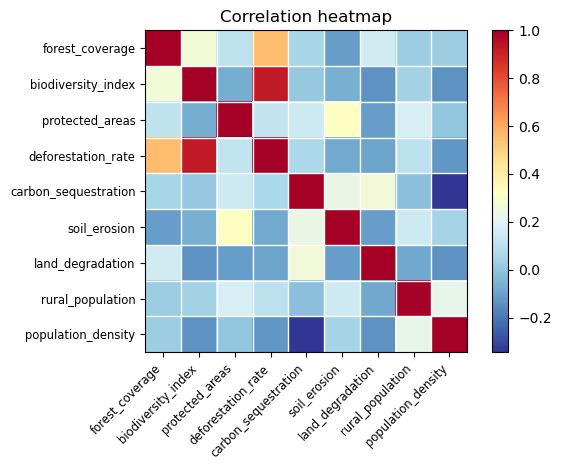

In [90]:
fig = sgc.plot_corr(corr_matrix, xnames=corr_matrix.columns)

plt.title("Correlation heatmap")
plt.show()

Knowing what we know about the relationships between the variables, it's time to build our regression model. To get started, include all the numeric variables in the model. Remember that biodiversity_index is the dependent variable.

Print the summary of the fitted model.



In [91]:
independent_cols = ['forest_coverage',  'protected_areas',
       'deforestation_rate', 'carbon_sequestration', 'soil_erosion',
       'land_degradation', 'rural_population', 'population_density']

dependent_var = 'biodiversity_index'

In [92]:
formula_string = f"biodiversity_index ~{'+'.join(independent_cols)}"


In [93]:
model = smf.ols(formula=formula_string, data=df)

In [94]:
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:     biodiversity_index   R-squared:                       0.967
Model:                            OLS   Adj. R-squared:                  0.956
Method:                 Least Squares   F-statistic:                     85.25
Date:                Mon, 03 Aug 2026   Prob (F-statistic):           2.99e-15
Time:                        15:06:20   Log-Likelihood:                -101.24
No. Observations:                  32   AIC:                             220.5
Df Residuals:                      23   BIC:                             233.7
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                0.2536 

Exercise 4

The output from this model seems somewhat strange, with a comment warning of probable multicollinearity. Furthermore, some of the coefficient p-values are rather high (larger than expected). It may be worthwhile to consider which variables appear to be associated with the dependent variable, maintaining those, and possibly removing a few additional factors where there is potential for multicollinearity.

Create another version of the model with fewer independent variables and see if the warning can be silenced.

In [95]:
independent_cols_reduced = ['forest_coverage',  'protected_areas',
       'deforestation_rate', 'soil_erosion',
        'rural_population']

dependent_var = 'biodiversity_index'

In [98]:
formula_str = f"biodiversity_index ~ {'+'.join(independent_cols_reduced)}"

model = smf.ols(formula = formula_str, data = df)

fitted = model.fit()

print(fitted.summary())

                            OLS Regression Results                            
Dep. Variable:     biodiversity_index   R-squared:                       0.966
Model:                            OLS   Adj. R-squared:                  0.959
Method:                 Least Squares   F-statistic:                     146.1
Date:                Mon, 03 Aug 2026   Prob (F-statistic):           3.59e-18
Time:                        15:19:23   Log-Likelihood:                -102.07
No. Observations:                  32   AIC:                             216.1
Df Residuals:                      26   BIC:                             224.9
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              1.4728      4

Evaluate the accuracy and reliability of the multiple linear regression model by conducting various diagnostic tests.

Check for linearity by visually inspecting scatter plots between each independent variable and the biodiversity index. This will help in understanding whether the relationship between the independent variables and the biodiversity index is linear.

What can we conclude from the charts? Are there any linear relationships visible?

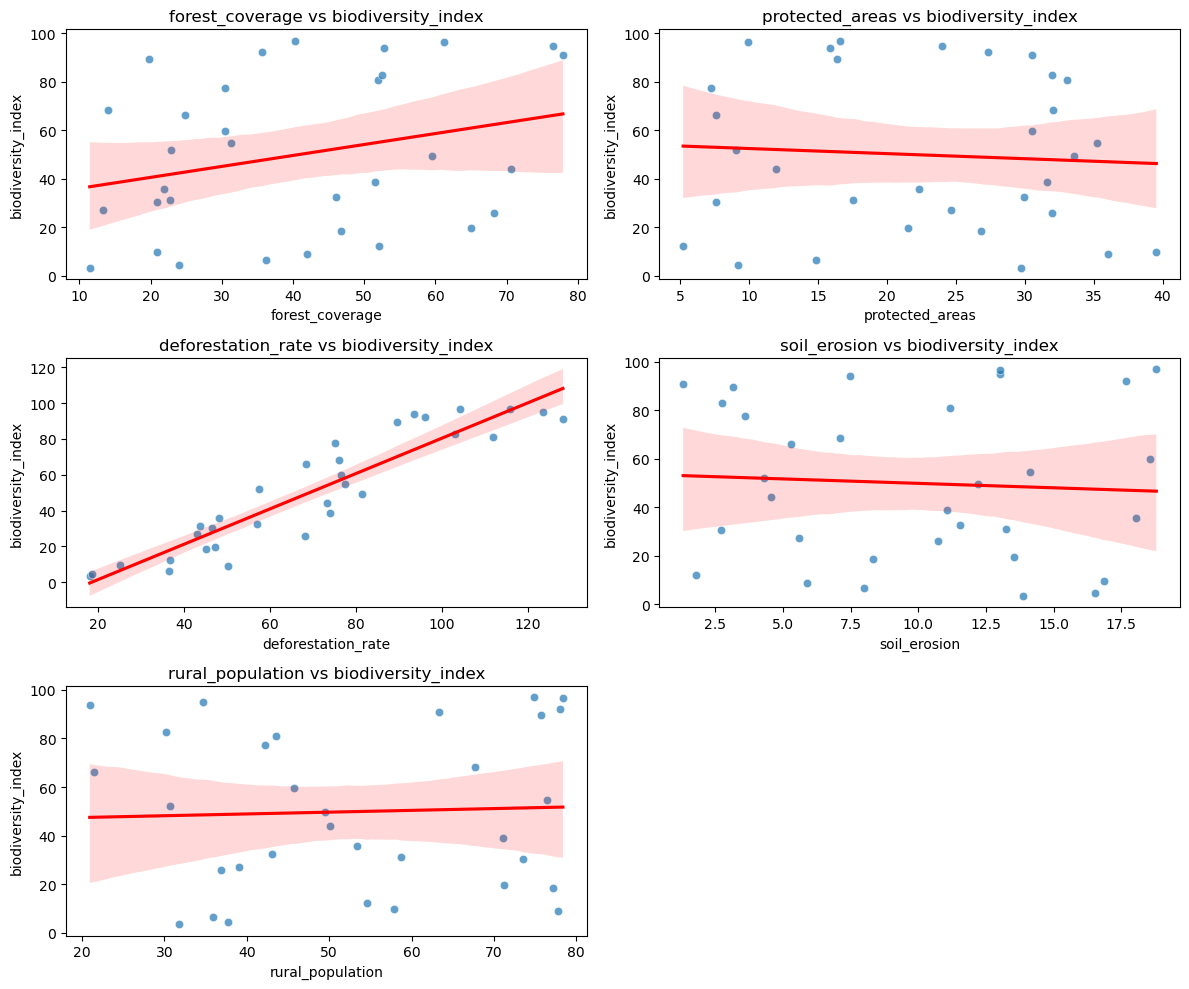

In [99]:
my_columns = ['forest_coverage',  'protected_areas',
       'deforestation_rate', 'soil_erosion',
        'rural_population'] 
target_var = 'biodiversity_index' # Your dependent variable

# 2. calculates how many rows are needed
num_vars = len(my_columns)
fig, axes = plt.subplots(nrows=(num_vars + 1) // 2, ncols=2, figsize=(12, num_vars * 2))
axes = axes.flatten()

# 3. The loop builds the plots
for i, var in enumerate(my_columns):
    sns.scatterplot(data=df, x=var, y=target_var, ax=axes[i], alpha=0.7)
    sns.regplot(data=df, x=var, y=target_var, ax=axes[i], scatter=False, color='red')
    axes[i].set_title(f'{var} vs {target_var}')

# Clean up empty spaces in the grid
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Exercise 6

Visualise the relationship between predictor variables and model residuals to assess the independence of residuals using scatter plots. Do we see any obvious dependence of residuals? How would we know?

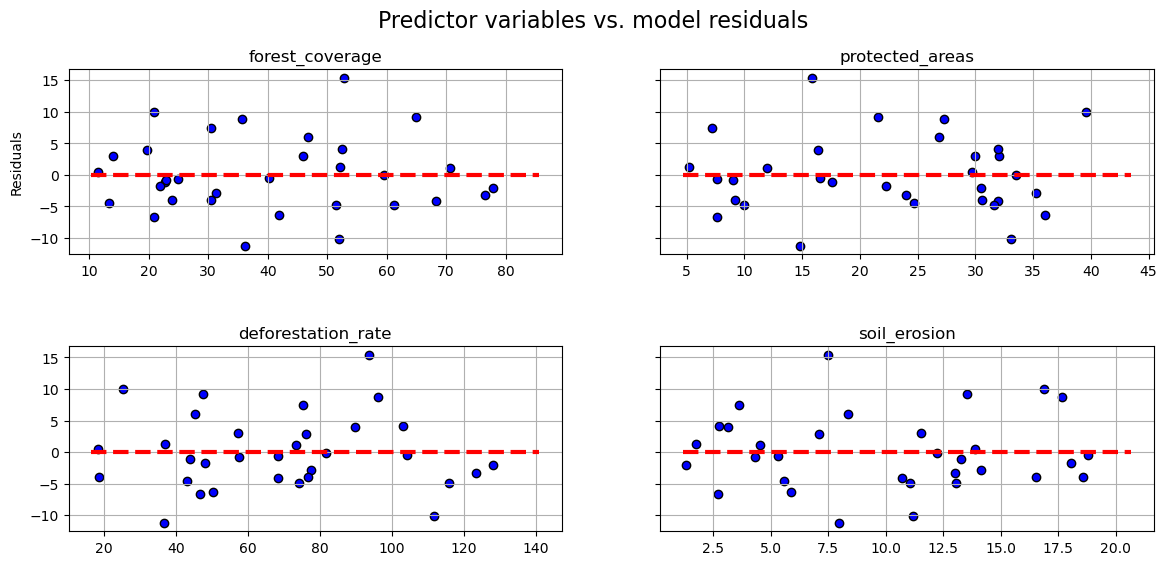

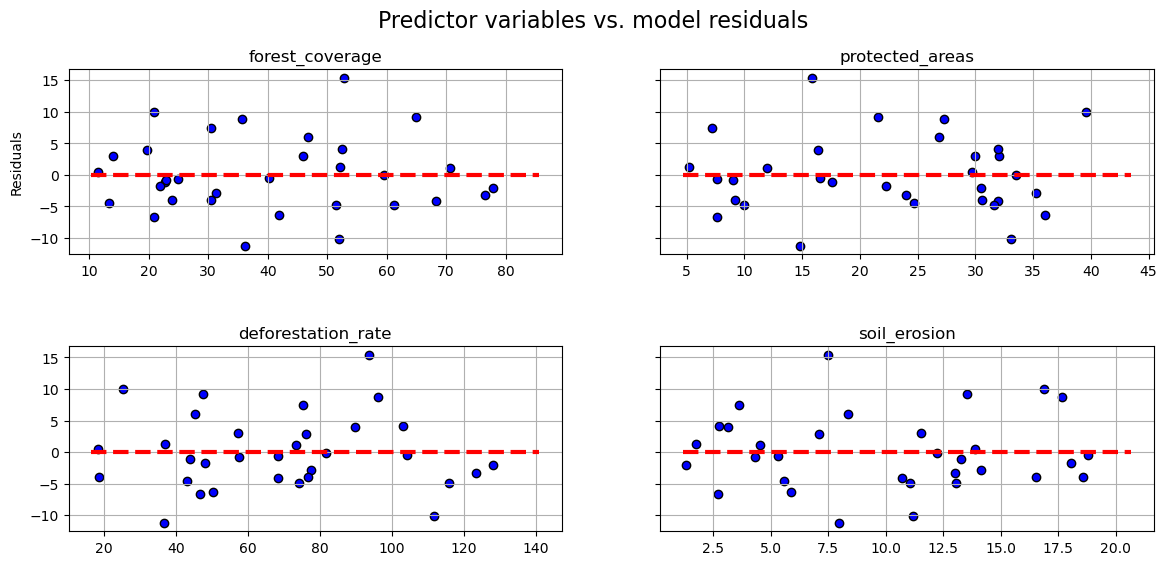

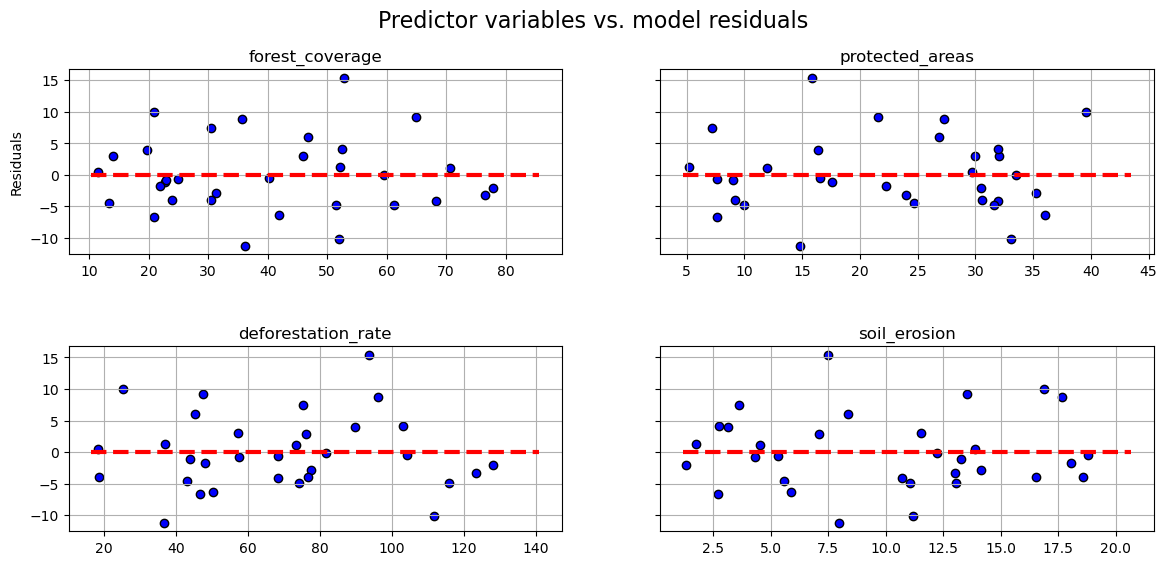

In [102]:
reduced_matrix = environmental_indicators[independent_cols_reduced]

# Plotting predictor variables vs. model residuals
fig, axs = plt.subplots(2, 2, figsize=(14, 6), sharey=True)  # Adjusted to 2 rows and 4 columns
fig.subplots_adjust(hspace=0.5, wspace=0.2)
fig.suptitle('Predictor variables vs. model residuals', fontsize=16)
axs = axs.ravel()

for index, column in enumerate(reduced_matrix):
    if index < len(axs):  # Ensure we don't exceed the number of subplots
        axs[index].set_title("{}".format(column), fontsize=12)
        axs[index].scatter(x=environmental_indicators[column], y=fitted.resid, color='blue', edgecolor='k')
        axs[index].grid(True)
        xmin = min(environmental_indicators[column])
        xmax = max(environmental_indicators[column])
        axs[index].hlines(y=0, xmin=xmin*0.9, xmax=xmax*1.1, color='red', linestyle='--', lw=3)
        if index == 0 or index == 4:
            axs[index].set_ylabel('Residuals')

plt.show()

Exercise 7

Check for homoscedasticity by conducting a Breusch-Pagan test on our model. Interpret the results to determine whether homoscedasticity could possibly be satisfied for our regression model.

In [103]:
# 1. Calculate residuals
residuals = fitted.resid

# 2. Perform Breusch-Pagan Test
bp_test_result = sms.het_breuschpagan(residuals, fitted.model.exog)
print("Breusch-Pagan Test Results:")
print("LM Statistic:", bp_test_result[0])
print("LM-Test p-value:", bp_test_result[1])
print("F-Statistic:", bp_test_result[2])
print("F-Test p-value:", bp_test_result[3])

Breusch-Pagan Test Results:
LM Statistic: 1.1642531323301064
LM-Test p-value: 0.9482604748380218
F-Statistic: 0.19633434902995867
F-Test p-value: 0.9611146316365257


Exercise 8

Check for the normality of residuals by creating a Q-Q plot of the normalised residuals to visually assess their normality

<Figure size 800x500 with 0 Axes>

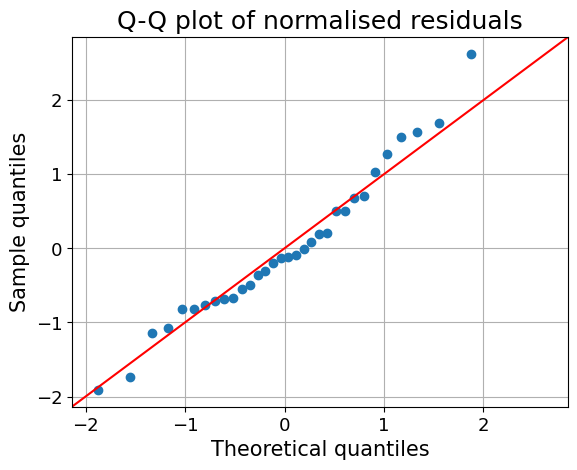

In [104]:
# Q-Q plot of normalised residuals
plt.figure(figsize=(8, 5))
fig = qqplot(fitted.resid_pearson, line='45', fit=True)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.xlabel("Theoretical quantiles", fontsize=15)
plt.ylabel("Sample quantiles", fontsize=15)
plt.title("Q-Q plot of normalised residuals", fontsize=18)
plt.grid(True)
plt.show()

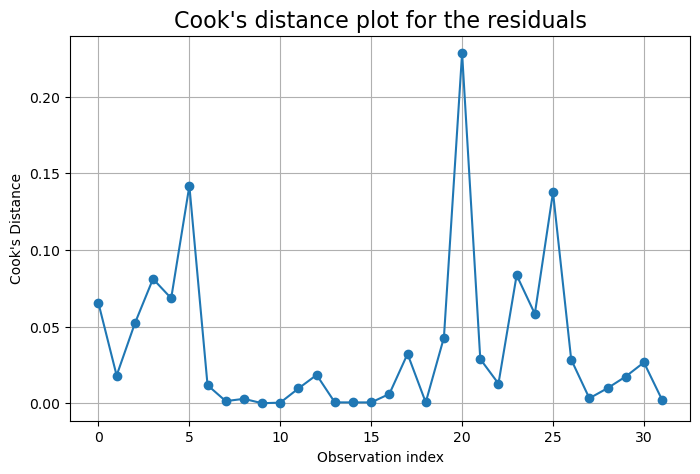

In [105]:
# Calculate Cook's distance
influence = OLSInfluence(fitted)
(c, p) = influence.cooks_distance

# Plot Cook's distance
plt.figure(figsize=(8, 5))
plt.title("Cook's distance plot for the residuals", fontsize=16)
plt.plot(np.arange(len(c)), c, marker='o', linestyle='-')
plt.xlabel('Observation index')
plt.ylabel("Cook's Distance")
plt.grid(True)
plt.show()

In [106]:
# 1. Set a threshold (0.5 is standard, or use 4/len(df) for a stricter check)
threshold = 0.125 

# 2. Find the index numbers where Cook's distance crosses the threshold
outlier_indices = np.where(c > threshold)[0]

print("Exact row indices to remove:", outlier_indices)


Exact row indices to remove: [ 5 20 25]
